In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
 

In [3]:
print("=" * 60)
print("  MOVIE RATING PREDICTION — IMDb India")
print("=" * 60)
 
df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')
print(f"\n[1] Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"    Columns: {', '.join(df.columns)}")

  MOVIE RATING PREDICTION — IMDb India

[1] Dataset loaded: 15,509 rows × 10 columns
    Columns: Name, Year, Duration, Genre, Rating, Votes, Director, Actor 1, Actor 2, Actor 3


In [4]:
print("\n[2] Cleaning data...")
 
# Year: extract 4-digit year
df['Year'] = pd.to_numeric(
    df['Year'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce'
)
 
# Duration: extract minutes
df['Duration_mins'] = pd.to_numeric(
    df['Duration'].astype(str).str.extract(r'(\d+)')[0], errors='coerce'
)
 
# Votes: numeric
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
 
# Drop rows without target (Rating)
before = len(df)
df = df.dropna(subset=['Rating'])
print(f"    Dropped {before - len(df):,} rows with missing Rating")
print(f"    Working dataset: {len(df):,} rows")
 
print(f"\n    Rating stats:")
print(f"      Min:    {df['Rating'].min()}")
print(f"      Max:    {df['Rating'].max()}")
print(f"      Mean:   {df['Rating'].mean():.2f}")
print(f"      Median: {df['Rating'].median():.2f}")
print(f"      Std:    {df['Rating'].std():.2f}")


[2] Cleaning data...
    Dropped 7,590 rows with missing Rating
    Working dataset: 7,919 rows

    Rating stats:
      Min:    1.1
      Max:    10.0
      Mean:   5.84
      Median: 6.00
      Std:    1.38


In [5]:
print("\n[3] Engineering features...")
 
# --- Genre features ---
df['Genre_primary'] = df['Genre'].fillna('Unknown').str.split(', ').str[0]
df['Genre_count']   = df['Genre'].fillna('').apply(lambda x: len(x.split(', ')) if x else 0)
 
# --- Log-transform votes (handles skew) ---
df['Log_votes'] = np.log1p(df['Votes'].fillna(0))
 
# --- Fill missing numerics with median ---
df['Year_filled']     = df['Year'].fillna(df['Year'].median())
df['Duration_filled'] = df['Duration_mins'].fillna(df['Duration_mins'].median())
 
# --- Encode primary genre ---
le_genre = LabelEncoder()
df['Genre_enc'] = le_genre.fit_transform(df['Genre_primary'])
 
# --- Actor popularity (total IMDb appearances as proxy for fame) ---
actor_pool  = pd.concat([df['Actor 1'], df['Actor 2'], df['Actor 3']]).value_counts()
df['Actor1_pop'] = df['Actor 1'].map(actor_pool).fillna(0)
df['Actor2_pop'] = df['Actor 2'].map(actor_pool).fillna(0)
df['Actor3_pop'] = df['Actor 3'].map(actor_pool).fillna(0)
 
# --- Director features ---
dir_counts = df['Director'].value_counts()
df['Dir_pop']        = df['Director'].map(dir_counts).fillna(0)
df['Dir_avg_rating'] = df.groupby('Director')['Rating'].transform('mean').fillna(df['Rating'].mean())
 
FEATURES = [
    'Year_filled',      # Release year
    'Duration_filled',  # Film length in minutes
    'Genre_enc',        # Primary genre (encoded)
    'Genre_count',      # Number of genres
    'Log_votes',        # Log of vote count
    'Actor1_pop',       # Lead actor popularity
    'Actor2_pop',       # Supporting actor 1 popularity
    'Actor3_pop',       # Supporting actor 2 popularity
    'Dir_pop',          # Director's filmography size
    'Dir_avg_rating',   # Director's historical avg rating ← most predictive
]
 
FEATURE_LABELS = [
    'Year', 'Duration', 'Genre', 'Genre Count', 'Log Votes',
    'Actor 1 Pop', 'Actor 2 Pop', 'Actor 3 Pop',
    'Director Pop', 'Director Avg Rating'
]
 
X = df[FEATURES]
y = df['Rating']
 
print(f"    Features ({len(FEATURES)}): {', '.join(FEATURES)}")
print(f"    Samples : {len(X):,}")
 


[3] Engineering features...
    Features (10): Year_filled, Duration_filled, Genre_enc, Genre_count, Log_votes, Actor1_pop, Actor2_pop, Actor3_pop, Dir_pop, Dir_avg_rating
    Samples : 7,919


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n[4] Train/Test split (80/20):")
print(f"    Train: {len(X_train):,} samples")
print(f"    Test : {len(X_test):,} samples")


[4] Train/Test split (80/20):
    Train: 6,335 samples
    Test : 1,584 samples


In [7]:
print("\n[5] Training models...")
print(f"\n    {'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'CV R²':>8}")
print(f"    {'-'*25} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
 
MODELS = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                     max_depth=4, random_state=42),
}
 
results   = {}
all_preds = {}
 
kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
for name, model in MODELS.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
 
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    cv   = cross_val_score(model, X, y, cv=kf, scoring='r2').mean()
 
    results[name]   = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_R2': cv}
    all_preds[name] = preds
 
    print(f"    {name:<25} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f} {cv:>8.4f}")
 
# Best model
best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = MODELS[best_name]
best_preds = all_preds[best_name]
print(f"\n    ✓ Best model: {best_name}  (R² = {results[best_name]['R2']:.4f})")


[5] Training models...

    Model                         RMSE      MAE       R²    CV R²
    ------------------------- -------- -------- -------- --------
    Linear Regression           0.8263   0.5622   0.6327   0.6316
    Ridge Regression            0.8263   0.5623   0.6327   0.6316
    Random Forest               0.7994   0.5331   0.6563   0.6558
    Gradient Boosting           0.7820   0.5290   0.6711   0.6732

    ✓ Best model: Gradient Boosting  (R² = 0.6711)


In [8]:
rf_model     = MODELS['Random Forest']
importances  = rf_model.feature_importances_
feat_imp_df  = pd.DataFrame({
    'Feature':    FEATURE_LABELS,
    'Importance': importances
}).sort_values('Importance', ascending=False)
 
print("\n[6] Feature Importances (Random Forest):")
for _, row in feat_imp_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"    {row['Feature']:<22} {row['Importance']:.4f}  {bar}")


[6] Feature Importances (Random Forest):
    Director Avg Rating    0.6758  █████████████████████████████████
    Year                   0.0614  ███
    Log Votes              0.0578  ██
    Director Pop           0.0433  ██
    Duration               0.0362  █
    Actor 2 Pop            0.0337  █
    Actor 1 Pop            0.0333  █
    Actor 3 Pop            0.0329  █
    Genre                  0.0175  
    Genre Count            0.0081  



[7] Generating visualizations...
    ✓ Saved: movie_rating_prediction_results.png


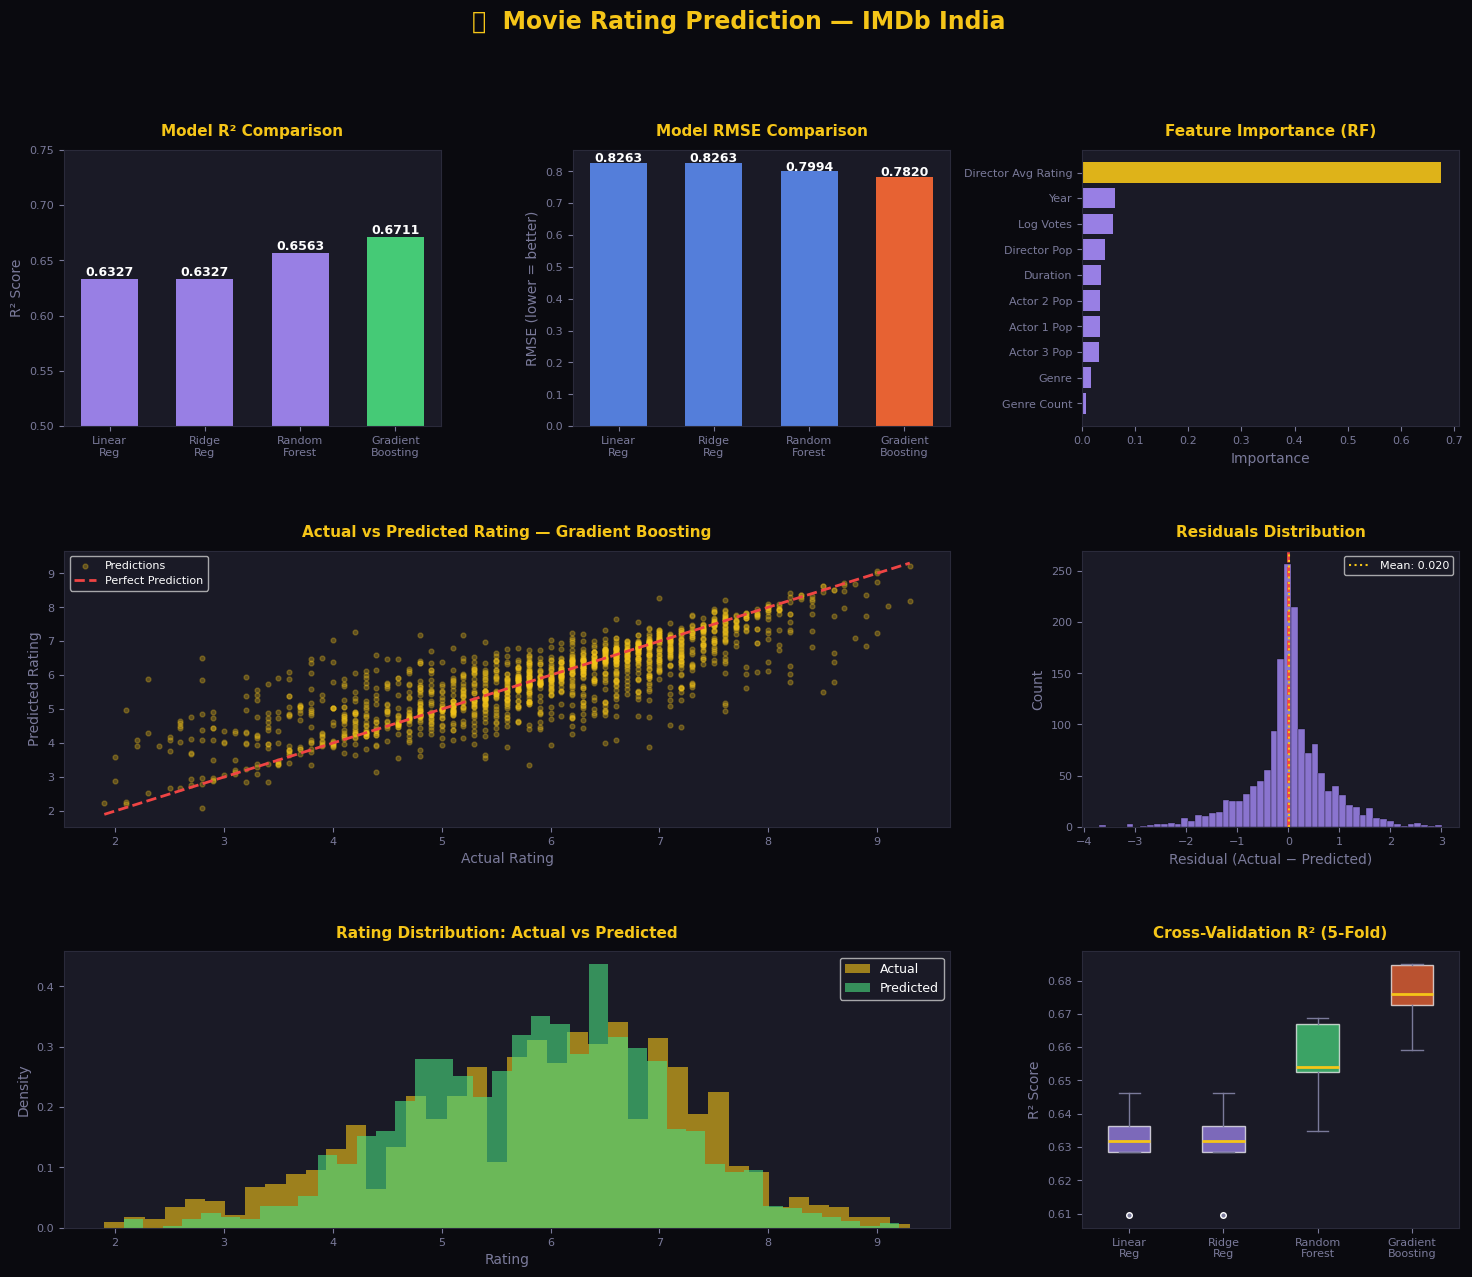

In [9]:
print("\n[7] Generating visualizations...")
 
plt.style.use('dark_background')
fig = plt.figure(figsize=(18, 14), facecolor='#0a0a0f')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
 
GOLD   = '#f5c518'
ORANGE = '#ff6b35'
PURPLE = '#a78bfa'
GREEN  = '#4ade80'
RED    = '#ef4444'
MUTED  = '#7a7a9a'
BG     = '#1a1a26'
 
def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=GOLD, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color('#2a2a3a')
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
 
fig.suptitle('🎬  Movie Rating Prediction — IMDb India',
             fontsize=17, fontweight='bold', color=GOLD, y=0.98)
 
# ── Plot 1: Model Comparison (R²) ──
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, 'Model R² Comparison')
names = list(results.keys())
r2s   = [results[n]['R2'] for n in names]
short = ['Linear\nReg', 'Ridge\nReg', 'Random\nForest', 'Gradient\nBoosting']
colors = [GREEN if n == best_name else PURPLE for n in names]
bars = ax1.bar(short, r2s, color=colors, alpha=0.9, width=0.6)
ax1.set_ylim(0.5, 0.75)
ax1.set_ylabel('R² Score')
for bar, val in zip(bars, r2s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', color='white', fontsize=9, fontweight='bold')
 
# ── Plot 2: RMSE Comparison ──
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, 'Model RMSE Comparison')
rmses = [results[n]['RMSE'] for n in names]
colors2 = [ORANGE if n == best_name else '#5b8aef' for n in names]
bars2 = ax2.bar(short, rmses, color=colors2, alpha=0.9, width=0.6)
ax2.set_ylabel('RMSE (lower = better)')
for bar, val in zip(bars2, rmses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', color='white', fontsize=9, fontweight='bold')
 
# ── Plot 3: Feature Importance ──
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, 'Feature Importance (RF)')
fi_sorted = feat_imp_df.sort_values('Importance')
bar_colors = [GOLD if i == len(fi_sorted)-1 else PURPLE for i in range(len(fi_sorted))]
ax3.barh(fi_sorted['Feature'], fi_sorted['Importance'], color=bar_colors, alpha=0.9)
ax3.set_xlabel('Importance')
 
# ── Plot 4: Actual vs Predicted (Best Model) ──
ax4 = fig.add_subplot(gs[1, 0:2])
style_ax(ax4, f'Actual vs Predicted Rating — {best_name}')
ax4.scatter(y_test, best_preds, alpha=0.3, color=GOLD, s=12, label='Predictions')
mn, mx = min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())
ax4.plot([mn, mx], [mn, mx], color=RED, lw=2, linestyle='--', label='Perfect Prediction')
ax4.set_xlabel('Actual Rating')
ax4.set_ylabel('Predicted Rating')
ax4.legend(fontsize=8, facecolor=BG, labelcolor='white')
 
# ── Plot 5: Residuals ──
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5, 'Residuals Distribution')
residuals = y_test.values - best_preds
ax5.hist(residuals, bins=50, color=PURPLE, alpha=0.8, edgecolor='#0a0a0f', linewidth=0.3)
ax5.axvline(0, color=RED, linewidth=2, linestyle='--')
ax5.axvline(residuals.mean(), color=GOLD, linewidth=1.5, linestyle=':', label=f'Mean: {residuals.mean():.3f}')
ax5.set_xlabel('Residual (Actual − Predicted)')
ax5.set_ylabel('Count')
ax5.legend(fontsize=8, facecolor=BG, labelcolor='white')
 
# ── Plot 6: Rating Distribution Actual vs Predicted ──
ax6 = fig.add_subplot(gs[2, 0:2])
style_ax(ax6, 'Rating Distribution: Actual vs Predicted')
ax6.hist(y_test, bins=40, alpha=0.6, color=GOLD,   label='Actual',    density=True)
ax6.hist(best_preds, bins=40, alpha=0.6, color=GREEN, label='Predicted', density=True)
ax6.set_xlabel('Rating')
ax6.set_ylabel('Density')
ax6.legend(fontsize=9, facecolor=BG, labelcolor='white')
 
# ── Plot 7: CV Scores ──
ax7 = fig.add_subplot(gs[2, 2])
style_ax(ax7, 'Cross-Validation R² (5-Fold)')
cv_scores_all = {}
for name, model in MODELS.items():
    cv_scores_all[name] = cross_val_score(model, X, y, cv=5, scoring='r2')
 
bp = ax7.boxplot(
    [cv_scores_all[n] for n in names],
    labels=short,
    patch_artist=True,
    medianprops=dict(color=GOLD, linewidth=2),
    whiskerprops=dict(color=MUTED),
    capprops=dict(color=MUTED),
    flierprops=dict(markerfacecolor=MUTED, markersize=4),
)
for patch, color in zip(bp['boxes'], [PURPLE, PURPLE, GREEN, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax7.set_ylabel('R² Score')
 
plt.savefig('movie_rating_prediction_results.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
print("    ✓ Saved: movie_rating_prediction_results.png")
plt.show()

In [10]:
print("\n[8] Example: Predicting rating for a new movie...")
 
# Simulate a new movie input
sample = pd.DataFrame([{
    'Year_filled':     2023,
    'Duration_filled': 145,
    'Genre_enc':       le_genre.transform(['Drama'])[0],
    'Genre_count':     2,
    'Log_votes':       np.log1p(5000),
    'Actor1_pop':      178,    # Amitabh Bachchan-level popularity
    'Actor2_pop':      90,
    'Actor3_pop':      45,
    'Dir_pop':         22,
    'Dir_avg_rating':  7.5,
}])
 
for name, model in MODELS.items():
    pred = model.predict(sample)[0]
    print(f"    {name:<25} → Predicted Rating: {pred:.2f}")


[8] Example: Predicting rating for a new movie...
    Linear Regression         → Predicted Rating: 7.22
    Ridge Regression          → Predicted Rating: 7.22
    Random Forest             → Predicted Rating: 7.06
    Gradient Boosting         → Predicted Rating: 6.07


In [11]:
print("\n" + "=" * 60)
print("  FINAL SUMMARY")
print("=" * 60)
print(f"\n  Dataset         : {len(df):,} rated Indian movies")
print(f"  Features Used   : {len(FEATURES)}")
print(f"  Train Samples   : {len(X_train):,}")
print(f"  Test Samples    : {len(X_test):,}")
print(f"\n  Best Model      : {best_name}")
print(f"  Best R²         : {results[best_name]['R2']:.4f}  (explains {results[best_name]['R2']*100:.1f}% of variance)")
print(f"  Best RMSE       : {results[best_name]['RMSE']:.4f}  (avg prediction error ±{results[best_name]['RMSE']:.2f} stars)")
print(f"  Best MAE        : {results[best_name]['MAE']:.4f}")
print(f"\n  Top Feature     : Director Avg Rating (importance: {importances[feat_imp_df.index[0]]:.4f})")
print(f"\n  Output Files    :")
print(f"    ✓ movie_rating_prediction_results.png")
print("\n" + "=" * 60)


  FINAL SUMMARY

  Dataset         : 7,919 rated Indian movies
  Features Used   : 10
  Train Samples   : 6,335
  Test Samples    : 1,584

  Best Model      : Gradient Boosting
  Best R²         : 0.6711  (explains 67.1% of variance)
  Best RMSE       : 0.7820  (avg prediction error ±0.78 stars)
  Best MAE        : 0.5290

  Top Feature     : Director Avg Rating (importance: 0.6758)

  Output Files    :
    ✓ movie_rating_prediction_results.png

